In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import seaborn.objects as so
import matplotlib.pyplot as plt

# Ejercicio 1 : Limpieza y Procesamiento de Datos

### Ejercicio 1, inciso 1

Cargar en un DataFrame df_jugadores los datos del archivo jugadores.csv.

In [2]:
df_jugadores = pd.read_csv("jugadores.csv")
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,21.9,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back


1245 filas y 98 columnas.

In [3]:
# Para referencia en próximos ejercicios, veamos la cantidad de datos nulos por columna.

df_jugadores.isna().sum()

player_id                          0
seleccion                          0
numero                             0
posicion                           0
jugador                            0
                                ... 
keeper_penalty_kicks_savepct    1168
keeper_playing_time_90s         1190
nat3                             325
valor_mercado_eur                 42
posicion_tm                       30
Length: 98, dtype: int64

In [4]:
# Datos duplicados por columna

df_jugadores.duplicated().sum()

np.int64(0)

In [5]:
# Tipos de datos
df_jugadores.dtypes

player_id                         int64
seleccion                        object
numero                            int64
posicion                         object
jugador                          object
                                 ...   
keeper_penalty_kicks_savepct    float64
keeper_playing_time_90s         float64
nat3                             object
valor_mercado_eur               float64
posicion_tm                      object
Length: 98, dtype: object

### Ejercicio 1, inciso 2

#### 2.a 
Contar cuántos jugadores tenemos por selección. ¿Hay la misma cantidad de jugadores para todas las selecciones? ¿Cuáles son las selecciones con menos jugadores convocados? 

In [6]:
# Dentro de un nuevo dataframe observamos cuántos jugadores hay por cada selección, 
# para eso filtramos por la columna 'seleccion'.
df_jugadores_por_seleccion = df_jugadores["seleccion"].value_counts().reset_index()

# Damos nombres a las columnas para facilitar su lectura.
df_jugadores_por_seleccion.columns = ['seleccion', 'cant_jugadores']

df_jugadores_por_seleccion

,seleccion,cant_jugadores
0,Czech Republic,26
1,Mexico,26
2,South Africa,26
3,South Korea,26
4,Bosnia and Herzegovina,26
5,Qatar,26
6,Switzerland,26
7,Brazil,26
8,Australia,26
9,Haiti,26


In [7]:
# Filtro por selecciones que tengan menos de 26 jugadores.
df_jugadores_por_seleccion[df_jugadores_por_seleccion["cant_jugadores"] < 26]

,seleccion,cant_jugadores
45,Canada,25
46,Jordan,25
47,Austria,25


La mayoría de los países tiene 26 jugadores en su selección, a excepción de Canada, Jordan y Austria que tienen exactamente 25.

#### 2.b

Mostrar los clubes con al menos 10 jugadores convocados al Mundial

In [8]:
# Similarmente a lo que hicimos con las selecciones, podemos observar cuántos jugadores hay por cada club.
df_jugadores_por_clubes = df_jugadores["club"].value_counts().reset_index()

# Idem con los nombres de las columnas.
df_jugadores_por_clubes.columns = ["club", "cant_jugadores"]

df_jugadores_por_clubes

,club,cant_jugadores
0,Manchester City,19
1,Bayern Munich,18
2,Paris Saint-Germain,16
3,Arsenal,16
4,Barcelona,15
...,...,...
444,Montpellier,1
445,Atromitos,1
446,St Patrick's Athletic,1
447,Hearts of Oak,1


In [9]:
# Filtro por clubes que tengan más de 9 jugadores en resumen.
clubes_con_10_o_mas = df_jugadores_por_clubes[df_jugadores_por_clubes["cant_jugadores"] > 9]
clubes_con_10_o_mas.sort_values("cant_jugadores", ascending=False)

,club,cant_jugadores
0,Manchester City,19
1,Bayern Munich,18
2,Paris Saint-Germain,16
3,Arsenal,16
4,Barcelona,15
5,Atlético Madrid,12
6,Al-Hilal,12
7,Manchester United,12
8,Crystal Palace,12
9,Galatasaray,11


#### 2.c

Agregar la columna *rango_etario* tal que si el jugador tiene menos de 24 años, su rango etario sea ’A’; 

si tiene entre 24 y 30 años sea ’B’;

si tiene 31 años o más, sea ’C’. 

¿Cuál es el rango etario dominante en las primeras cinco selecciones del Ranking FIFA?

In [10]:
# Definimos una función que dada la edad devuelva la categoría
def rangos_etarios(edad):
    if edad < 24:
        return "A"
    elif 24 <= edad <= 30:
        return "B"
    else:
        return "C"

# Creamos la columnas 'rango_etario' aplicando la función definida anteriormente con los valores de la columna 'edad 
df_jugadores["rango_etario"] = df_jugadores["edad"].apply(rangos_etarios)
df_jugadores[["jugador", "edad", "rango_etario"]]

,jugador,edad,rango_etario
0,Matěj Kovář,26,B
1,David Zima,25,B
2,Tomáš Holeš,33,C
3,Robin Hranáč,26,B
4,Vladimír Coufal,33,C
...,...,...,...
1240,Orlando Mosquera,31,C
1241,Michael Amir Murillo,30,B
1242,Azarias Londoño,24,B
1243,Roderick Miller,34,C


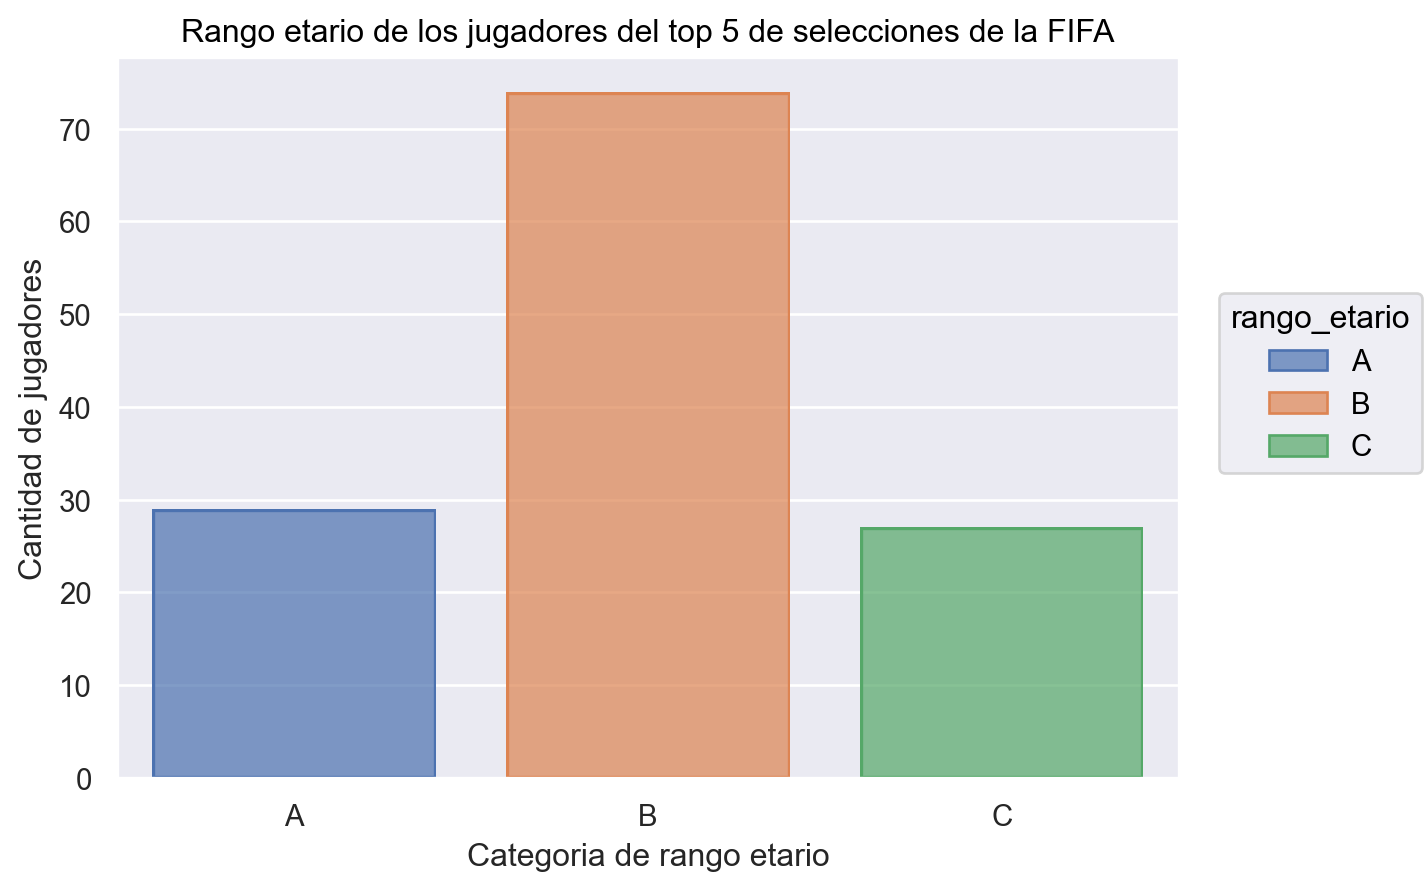

In [11]:
# Creo un array del top 5 de selecciones de la FIFA para filtar mi columna de seleccion
# (referencia: sitio https://inside.fifa.com/es/fifa-world-ranking/men en la fecha 16 de junio)
top_5_fifa = np.array(['Argentina', 'France', 'Spain', 'England', 'Portugal'])

df_top_5_fifa = df_jugadores[df_jugadores["seleccion"].isin(top_5_fifa)]

(   # Plot gráfico de barras, eje x = 'rango_etario' y eje y = cantidad de jugadores
    so.Plot(
        df_top_5_fifa,
        x = 'rango_etario',
        color='rango_etario',
    )
    .add(so.Bar(), so.Count())
    .scale( # Arreglamos el orden de las variables categóricas
        x = so.Nominal(order=['A', 'B', 'C']), 
        color = so.Nominal(order=['A', 'B', 'C'])
    )
    .label(
        title='Rango etario de los jugadores del top 5 de selecciones de la FIFA',
        x='Categoria de rango etario',
        y='Cantidad de jugadores')
)

A : Menores de 24 años. 

B : Entre 24 y 30 años inclusive.

C : Mayores de 30 años.

Es clara la distribución etaria en el gráfico siendo mayoría (por no decir casi más del doble) los jugadores de entre 24 y 30 años inclusive.

### Ejercicio 1, inciso 3

 Hay distintos grupos de variables, algunos de estos grupos solo estan disponibles para jugadores de las ligas europeas y vamos a eliminarlas. 

 Analizar para una variable de cada uno de los siguientes grupos cuantos jugadores tienen esa informacion y eliminar los grupos de variables que tengan cobertura menor al 60 % (es decir que solo esten disponibles para menos del 60 % de los jugadoes: standard_, shooting_, misc_performance_,playing_time_, shooting_)

In [12]:
# En primer lugar para facilitar la legibilidad y el trabajo, guardamos en una variable los filtros de columnas.
# usando el nombre con el que empieza.
shooting_columns = df_jugadores.columns[df_jugadores.columns.str.startswith("shooting_")]
standard_columns = df_jugadores.columns[df_jugadores.columns.str.startswith("standard_")]
misc_performance_columns = df_jugadores.columns[df_jugadores.columns.str.startswith("misc_performance_")]
playing_time_columns = df_jugadores.columns[df_jugadores.columns.str.startswith("playing_time_")]



In [13]:
# Columnas que comienzan con Shooting_
# Calculamos el porcentaje de cobertura de las columnas sobre la cantidad de jugadores
porcentaje_shooting = df_jugadores[shooting_columns].notna().sum() / df_jugadores.shape[0] 

# Filtramos los menores a 0.6
porcentaje_shooting_menor_60 = porcentaje_shooting[porcentaje_shooting < 0.6]

porcentaje_shooting_menor_60

# 1 sola columna de ~0.597 de cobertura.


shooting_standard_g_per_sot    0.59759
dtype: float64

In [14]:
# Standard_
# Mismo procedimiento que con las columnas Shooting_
porcentaje_standard = df_jugadores[standard_columns].notna().sum() / df_jugadores.shape[0]

porcentaje_standard_menor_60 = porcentaje_standard[porcentaje_standard < 0.6]

porcentaje_standard_menor_60

# Ninguna columna


Series([], dtype: float64)

In [15]:
# Misc_performance_
porcentaje_misc_performance = df_jugadores[misc_performance_columns].notna().sum() / df_jugadores.shape[0]

porcentaje_misc_performance_menor_60 = porcentaje_misc_performance[porcentaje_misc_performance < 0.6]
porcentaje_misc_performance_menor_60

# 2 Columnas


misc_performance_pkwon    0.0
misc_performance_pkcon    0.0
dtype: float64

In [16]:
# Playing_time_
porcentaje_playing_time = df_jugadores[playing_time_columns].notna().sum() / df_jugadores.shape[0]

porcentaje_playing_time_menor_60 = porcentaje_playing_time[porcentaje_playing_time < 0.6]
porcentaje_playing_time_menor_60

# 17 columnas

playing_time_playing_time_mp           0.382329
playing_time_playing_time_min          0.381526
playing_time_playing_time_mn_per_mp    0.381526
playing_time_playing_time_minpct       0.381526
playing_time_playing_time_90s          0.381526
playing_time_starts_starts             0.382329
playing_time_starts_mn_per_start       0.372691
playing_time_starts_compl              0.382329
playing_time_subs_subs                 0.382329
playing_time_subs_mn_per_sub           0.326104
playing_time_subs_unsub                0.382329
playing_time_team_success_ppm          0.381526
playing_time_team_success_ong          0.381526
playing_time_team_success_onga         0.381526
playing_time_team_success_p_per_-      0.381526
playing_time_team_success_p_per_-90    0.381526
playing_time_team_success_on-off       0.375904
dtype: float64

In [17]:
# Eliminamos las columnas de nuestro dataframe de base
# 1 columna
df_jugadores.drop(columns=porcentaje_shooting_menor_60.index, inplace=True)

# 2 columnas
df_jugadores.drop(columns=porcentaje_misc_performance_menor_60.index, inplace=True)

# 17 columnas
df_jugadores.drop(columns= porcentaje_playing_time_menor_60.index, inplace=True)


In [18]:
df_jugadores.head(5)

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back,C


### Ejercicio 1, inciso 4

Dentro del grupo shooting_ hay variables de ratios que solo se calculan cuando el jugador hizo tiros, y estan NA en otros casos, ¿como podemos tratar los NA en este caso para no eliminar la variable?

In [19]:
shooting_columns.tolist()

# Glosario de FBRef :

# shooting_90s : Minutes played divided by 90.
# shooting_standard_gls : Goals scored or allowed.
# shooting_standard_sh : Shots (tiros al arco). Does not include penalty kicks. 
# shooting_standard_sot : Shots on target. 

# shooting_standard_sotpct : Percentage of shots that are on target. Calculated as (shooting_standard_sot / shooting_standard_sh) * 100.
# shooting_standard_sh_per_90 : Shots per 90 minutes. Calculated as (shooting_standard_sh / shooting_90s).
# shooting_standard_sot_per_90 : Shots on target per 90 minutes. Calculated as (shooting_standard_sot / shooting_90s).
# shooting_standard_g_per_sh : Goals per shot. Calculated as (shooting_standard_gls / shooting_standard_sh).
# shooting_standard_g_per_sot : Goals per shot on target. Calculated as (shooting_standard_gls / shooting_standard_sot).

# shooting_standard_pk : Penalty kicks. Does not include penalty kick shootouts.
# shooting_standard_pkatt : Penalty kick attempts. Does not include penalty kick shootouts.

['shooting_90s',
 'shooting_standard_gls',
 'shooting_standard_sh',
 'shooting_standard_sot',
 'shooting_standard_sotpct',
 'shooting_standard_sh_per_90',
 'shooting_standard_sot_per_90',
 'shooting_standard_g_per_sh',
 'shooting_standard_g_per_sot',
 'shooting_standard_pk',
 'shooting_standard_pkatt']

In [20]:
# Veo las columnas 'shooting_' de df que tienen NA.

df_shooting_na = df_jugadores[[col for col in df_jugadores.columns if col.startswith("shooting_") and df_jugadores[col].isna().any()]]
df_shooting_na.columns.tolist()

['shooting_90s',
 'shooting_standard_gls',
 'shooting_standard_sh',
 'shooting_standard_sot',
 'shooting_standard_sotpct',
 'shooting_standard_sh_per_90',
 'shooting_standard_sot_per_90',
 'shooting_standard_g_per_sh',
 'shooting_standard_pk',
 'shooting_standard_pkatt']

Las columnas de valores ratio o de porcentaje son:
* shooting_standard_sotpct
* shooting_standard_sh_per_90
* shooting_standard_sot_per_90
* shooting_standard_g_per_sh

Son datos faltantes que si no existen es porque no hay tiros ni goles.
Podemos llenar esas celdas con 0.

In [21]:
shooting_pct_con_na = ['shooting_standard_sotpct', 'shooting_standard_sh_per_90', 'shooting_standard_sot_per_90', 'shooting_standard_g_per_sh']

df_jugadores[shooting_pct_con_na] = df_jugadores[shooting_pct_con_na].fillna(0)

df_jugadores[shooting_pct_con_na].isna().sum()

shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
shooting_standard_g_per_sh      0
dtype: int64

### Ejercicio 1, inciso 5

¿Como analizan la variables del grupo **keeper_**? ¿Que cobertura tienen y  a  que  se  puede  deber?  ¿Como  lo  podemos  solucionar  sin  eliminar  las columnas?

In [22]:
keeper_columnas = [col for col in df_jugadores.columns if col.startswith('keeper_')]

df_jugadores[keeper_columnas]

,keeper_playing_time_mp,keeper_playing_time_starts,keeper_playing_time_min,keeper_90s,keeper_performance_ga,keeper_performance_ga90,keeper_performance_sota,keeper_performance_saves,keeper_performance_savepct,keeper_performance_w,keeper_performance_d,keeper_performance_l,keeper_performance_cs,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s
0,31.0,31.0,2790.0,NaN,41.0,1.32,123.0,85.0,69.1,25.0,3.0,3.0,7.0,22.6,4.0,3.0,0.0,1.0,0.0,31.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,32.0,32.0,2880.0,NaN,50.0,1.56,138.0,92.0,65.2,9.0,8.0,15.0,7.0,21.9,6.0,2.0,2.0,2.0,50.0,32.0
1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
cobertura_keeper_col = df_jugadores[keeper_columnas].count() /len(df_jugadores)
print(cobertura_keeper_col.sort_values)

<bound method Series.sort_values of keeper_playing_time_mp          0.072289
keeper_playing_time_starts      0.072289
keeper_playing_time_min         0.072289
keeper_90s                      0.028112
keeper_performance_ga           0.072289
keeper_performance_ga90         0.072289
keeper_performance_sota         0.067470
keeper_performance_saves        0.067470
keeper_performance_savepct      0.066667
keeper_performance_w            0.072289
keeper_performance_d            0.072289
keeper_performance_l            0.072289
keeper_performance_cs           0.072289
keeper_performance_cspct        0.071486
keeper_penalty_kicks_pkatt      0.072289
keeper_penalty_kicks_pka        0.072289
keeper_penalty_kicks_pksv       0.072289
keeper_penalty_kicks_pkm        0.072289
keeper_penalty_kicks_savepct    0.061847
keeper_playing_time_90s         0.044177
dtype: float64>


In [24]:
df_jugadores['posicion'].value_counts(normalize = True)*100



posicion
DF    33.815261
MF    29.638554
FW    24.899598
GK    11.646586
Name: proportion, dtype: float64

La cobertura es igual o menor a ~0.08 (8%). Tratándose de arqueros, que representan el ~11.7 % de jugadores, son columnas que pueden llenarse de 0 para salvar los valores Na.



In [25]:
df_jugadores[keeper_columnas] = df_jugadores[keeper_columnas].fillna(0)

df_jugadores[keeper_columnas]

,keeper_playing_time_mp,keeper_playing_time_starts,keeper_playing_time_min,keeper_90s,keeper_performance_ga,keeper_performance_ga90,keeper_performance_sota,keeper_performance_saves,keeper_performance_savepct,keeper_performance_w,keeper_performance_d,keeper_performance_l,keeper_performance_cs,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s
0,31.0,31.0,2790.0,0.0,41.0,1.32,123.0,85.0,69.1,25.0,3.0,3.0,7.0,22.6,4.0,3.0,0.0,1.0,0.0,31.0
1,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,32.0,32.0,2880.0,0.0,50.0,1.56,138.0,92.0,65.2,9.0,8.0,15.0,7.0,21.9,6.0,2.0,2.0,2.0,50.0,32.0
1241,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1242,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1243,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Ejercicio 1, inciso 6

En base a lo trabajado en las preguntas anteriores, armar una base **df_jugadores_limpia** sin datos faltantes (deben quedar al menos **30 variables numericas** y **al menos 850 jugadores**).

In [26]:
df_jugadores.isna().sum()

player_id                    0
seleccion                    0
numero                       0
posicion                     0
jugador                      0
                          ... 
keeper_playing_time_90s      0
nat3                       325
valor_mercado_eur           42
posicion_tm                 30
rango_etario                 0
Length: 79, dtype: int64

Armo el nuevo dataframe para mis datos limpios:

In [27]:
df_jugadores_limpia = df_jugadores

#### Columnas nat3 y nation_fbref

In [28]:
columnas_nat_codfifa = ['cod_fifa', 'nat3', 'nation_fbref']
df_jugadores_limpia[columnas_nat_codfifa]

,cod_fifa,nat3,nation_fbref
0,CZE,CZE,CZE
1,CZE,CZE,CZE
2,CZE,CZE,CZE
3,CZE,CZE,CZE
4,CZE,CZE,CZE
...,...,...,...
1240,PAN,PAN,PAN
1241,PAN,PAN,PAN
1242,PAN,PAN,PAN
1243,PAN,NaN,NaN


Son columnas redudantes que se pueden despreciar.

In [29]:
df_jugadores_limpia = df_jugadores_limpia.drop(columns = ['nat3', 'nation_fbref'])
df_jugadores_limpia.head()

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7000000.0,Right-Back,C


#### Columna player_fbref

In [30]:
columnas_jugadores = ['jugador', 'player_fbref']
df_jugadores_limpia[columnas_jugadores]

,jugador,player_fbref
0,Matěj Kovář,Matej Kovar
1,David Zima,David Zima
2,Tomáš Holeš,Tomáš Holeš
3,Robin Hranáč,Robin Hranáč
4,Vladimír Coufal,Vladimír Coufal
...,...,...
1240,Orlando Mosquera,Orlando Mosquera
1241,Michael Amir Murillo,Michael Amir Murillo
1242,Azarias Londoño,Azarías Londoño
1243,Roderick Miller,NaN


In [31]:
df_jugadores_limpia = df_jugadores_limpia.drop(columns = 'player_fbref')



#### Columnas club_fbref y posicion_tm

In [32]:
df_jugadores_limpia = df_jugadores_limpia.drop(columns = ['club_fbref', 'posicion_tm'])

In [33]:
df_jugadores_limpia.head(3)

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cs,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,valor_mercado_eur,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,7.0,22.6,4.0,3.0,0.0,1.0,0.0,31.0,7000000.0,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4500000.0,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2200000.0,C


#### Columnas con datos faltantes : llenar con mediana valor_mercado_eur, buscar jugadores con poca cobertura en las estadisticas de juego.

#### Valor_mercado_eur

In [34]:
mediana_valor_mercado_eur = df_jugadores_limpia['valor_mercado_eur'].median()
df_jugadores_limpia['valor_mercado_eur'] = df_jugadores_limpia['valor_mercado_eur'].fillna(mediana_valor_mercado_eur)
df_jugadores_limpia['valor_mercado_eur'].isna().sum()

np.int64(0)

#### Columnas numericas

In [35]:
# Definimos las columnas que tengan algún NA (en este caso son todas las columnas numericas) y filtramos los jugadores que tengan NA en todas sus columnas numericas.

columnas_con_na = df_jugadores_limpia.columns[df_jugadores_limpia.isna().any()].tolist()

columnas_numericas = [col for col in columnas_con_na if col not in ['jugador', 'posicion']]

print(f"Jugadores antes de la limpieza: {len(df_jugadores_limpia)}")


df_jugadores_limpia = df_jugadores_limpia.dropna(subset=columnas_numericas, how='all')

# 4. Verificamos el resultado
print(f"Jugadores después de la limpieza: {len(df_jugadores_limpia)}")


Jugadores antes de la limpieza: 1245
Jugadores después de la limpieza: 922


In [36]:
# Filtramos las filas que tienen al menos un NA en cualquier columna
df_restantes_con_na = df_jugadores_limpia[df_jugadores_limpia.isna().any(axis=1)]

# Vemos cuántos jugadores problemáticos nos quedan
print(f"Quedan {len(df_restantes_con_na)} jugadores con algún dato faltante.")

# Identificamos rápidamente QUÉ columnas son las que tienen estos NAs
columnas_afectadas = df_restantes_con_na.columns[df_restantes_con_na.isna().any()].tolist()
print(f"Las columnas que aún presentan nulos son: {columnas_afectadas}")

# Mostramos los datos para inspeccionar visualmente
# Mostramos el nombre, posición y solo las columnas afectadas para que sea fácil de leer
columnas_vista = ['jugador', 'posicion'] + [col for col in columnas_afectadas if col not in ['jugador', 'posicion']]
df_restantes_con_na[columnas_vista]

Quedan 34 jugadores con algún dato faltante.
Las columnas que aún presentan nulos son: ['standard_playing_time_mp', 'standard_playing_time_starts', 'standard_playing_time_min', 'standard_playing_time_90s', 'standard_performance_gls', 'standard_performance_ast', 'standard_performance_gpa', 'standard_performance_g-pk', 'standard_performance_pk', 'standard_performance_pkatt', 'standard_performance_crdy', 'standard_performance_crdr', 'standard_per_90_minutes_gls', 'standard_per_90_minutes_ast', 'standard_per_90_minutes_gpa', 'standard_per_90_minutes_g-pk', 'standard_per_90_minutes_gpa-pk', 'shooting_standard_sh', 'shooting_standard_sot', 'misc_performance_fls', 'misc_performance_fld', 'misc_performance_off', 'misc_performance_crs', 'misc_performance_int', 'misc_performance_tklw']


,jugador,posicion,standard_playing_time_mp,standard_playing_time_starts,standard_playing_time_min,standard_playing_time_90s,standard_performance_gls,standard_performance_ast,standard_performance_gpa,standard_performance_g-pk,...,standard_per_90_minutes_g-pk,standard_per_90_minutes_gpa-pk,shooting_standard_sh,shooting_standard_sot,misc_performance_fls,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw
27,Jorge Sánchez,DF,10.0,7.0,633.0,7.0,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,Kim Jin-gyu,MF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.0,8.0,6.0,3.0,0.0,37.0,3.0,7.0
236,Ricardo Adé,DF,30.0,29.0,2620.0,29.1,1.0,0.0,1.0,1.0,...,0.03,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Duckens Nazon,FW,10.0,4.0,429.0,4.8,1.0,1.0,2.0,1.0,...,0.21,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,Frantzdy Pierrot,FW,9.0,5.0,539.0,6.0,2.0,2.0,4.0,2.0,...,0.33,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
354,Álex Arce,FW,12.0,11.0,990.0,11.0,3.0,3.0,6.0,2.0,...,0.18,0.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
445,Jordy Alcívar,MF,31.0,23.0,2078.0,23.1,2.0,2.0,4.0,2.0,...,0.09,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
462,Gonzalo Valle,GK,14.0,14.0,1215.0,13.5,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,Alban Lafont,GK,22.0,22.0,1935.0,21.5,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
675,Alireza Beiranvand,GK,19.0,19.0,1710.0,19.0,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# 1. Calculamos la cobertura exacta de cada jugador (sobre los que tienen algún NA)
cobertura_total = df_restantes_con_na.notna().mean(axis=1) * 100

# 2. Armamos un sub-DataFrame solo para visualizar esta información de forma limpia
df_vista_cobertura = df_restantes_con_na[['jugador', 'posicion']].copy()
df_vista_cobertura['%_cobertura'] = cobertura_total.round(2)
df_vista_cobertura['cant_na'] = df_restantes_con_na.isna().sum(axis=1)

# 3. Ordenamos de menor a mayor cobertura (los peores casos arriba)
df_vista_cobertura = df_vista_cobertura.sort_values(by='%_cobertura')


df_vista_cobertura

,jugador,posicion,%_cobertura,cant_na
101,Kim Jin-gyu,MF,77.03,17
27,Jorge Sánchez,DF,89.19,8
236,Ricardo Adé,DF,89.19,8
241,Duckens Nazon,FW,89.19,8
252,Frantzdy Pierrot,FW,89.19,8
354,Álex Arce,FW,89.19,8
445,Jordy Alcívar,MF,89.19,8
462,Gonzalo Valle,GK,89.19,8
515,Alban Lafont,GK,89.19,8
675,Alireza Beiranvand,GK,89.19,8


Agregar 0 en shooting para arqueros.

In [42]:
# En principio podemos asumir que los faltantes en shooting son igual 0 para arqueros al ser una posición muy definida
shooting_columns_limpia = [col for col in df_jugadores_limpia.columns if col.startswith('shooting_')]
df_jugadores_limpia.loc[df_jugadores_limpia['posicion'] == 'GK',shooting_columns_limpia] = df_jugadores_limpia.loc[df_jugadores_limpia['posicion'] == 'GK', shooting_columns_limpia].fillna(0)

df_jugadores_limpia.loc[df_jugadores_limpia['posicion'] == 'GK',shooting_columns_limpia].isna().sum()


shooting_90s                    0
shooting_standard_gls           0
shooting_standard_sh            0
shooting_standard_sot           0
shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
shooting_standard_g_per_sh      0
shooting_standard_pk            0
shooting_standard_pkatt         0
dtype: int64

In [43]:
df_restantes_con_na[columnas_vista]

,jugador,posicion,standard_playing_time_mp,standard_playing_time_starts,standard_playing_time_min,standard_playing_time_90s,standard_performance_gls,standard_performance_ast,standard_performance_gpa,standard_performance_g-pk,...,standard_per_90_minutes_g-pk,standard_per_90_minutes_gpa-pk,shooting_standard_sh,shooting_standard_sot,misc_performance_fls,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw
27,Jorge Sánchez,DF,10.0,7.0,633.0,7.0,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,Kim Jin-gyu,MF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.0,8.0,6.0,3.0,0.0,37.0,3.0,7.0
236,Ricardo Adé,DF,30.0,29.0,2620.0,29.1,1.0,0.0,1.0,1.0,...,0.03,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Duckens Nazon,FW,10.0,4.0,429.0,4.8,1.0,1.0,2.0,1.0,...,0.21,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,Frantzdy Pierrot,FW,9.0,5.0,539.0,6.0,2.0,2.0,4.0,2.0,...,0.33,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
354,Álex Arce,FW,12.0,11.0,990.0,11.0,3.0,3.0,6.0,2.0,...,0.18,0.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
445,Jordy Alcívar,MF,31.0,23.0,2078.0,23.1,2.0,2.0,4.0,2.0,...,0.09,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
462,Gonzalo Valle,GK,14.0,14.0,1215.0,13.5,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,Alban Lafont,GK,22.0,22.0,1935.0,21.5,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
675,Alireza Beiranvand,GK,19.0,19.0,1710.0,19.0,0.0,0.0,0.0,0.0,...,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Como son pocos los jugadores que me quedan con pocos datos en esas columnas y además tienen posiciones menos definidas que arquero y en NA en columnas menos específicas,
# podemos recuperar esa información con el average de jugadores que compartan posicion
mean_posicion= df_jugadores_limpia.groupby('posicion')[columnas_con_na].mean()

for col in columnas_con_na:
    promedio_map = df_jugadores_limpia['posicion'].map(mean_posicion[col])
    df_jugadores_limpia[col] = df_jugadores_limpia[col].fillna(promedio_map)
df_jugadores_limpia[columnas_con_na] = df_jugadores_limpia[columnas_con_na].round(2)


In [58]:
df_jugadores_limpia.isna().sum(axis=1)[lambda x: x > 0]

Series([], dtype: int64)

### Ejercicio 1, inciso 7

A partir de **df_jugadores_limpia** armar una base de datos **df_selecciones** que  contenga  solo  la  columna **seleccion**  y  las  variables  numericas  tomando el promedio de cada variable numerica para los jugadores de cada seleccion. _Eliminar primero a las selecciones con 3 o menos jugadores_ en df_jugadores_limpia.

#### Hacer

* Chequear jugadores que no aportan informacion, con mayoria de nulls en columnas de stats.
* estadistica de perfomance calculada para seleccion inciso 7
2 opciones:
opcion 1: seguro hay columnas de estadisticas generales (deben ser pocas) que tienen datos para todos los jugadores, en este caso se podria tomar el promedio de esos valores por seleccion
opcion 2: es mas compleja pero quizas divertida y precisa (para eso hay que evaluarlo y ver que resultado obtenemos), la opcion 2 seria crear tu propia variable perfomance, la cual estaria construida en base a la posicion de cada jugar con las estadisticas relevantes de esa posicion ej: perfomance_delantero= una ponderacion entre goles, asistencias, pases etc etc, mientras que para perfomance_arquero = una ponderacion entre , atajadas, goles recibidos etc etc, luego se podria concatenar estas perfomance de las posiciones teniendo un perfomance_personalizado_general (qeu seria la union de perfomance_arquero, perfomance_delantero, perfomance_defensor ....) a su vez tendriamos el perfomance del dataset, podriamos ahcer una comparacion de esos valores y finalmente promediar o qeudarnos con uno